## 1. Setup & Imports

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import importlib

import plot_helpers
importlib.reload(plot_helpers)
from plot_helpers import (
    setup_plotting_style,
    style_ax,
    get_step_formatter,
    save_figure,
    PAPER_WIDTH_IN,
    PAPER_HEIGHT_IN,
)

setup_plotting_style(style="paper")


In [2]:
def load_formal_language_hydra_data(experiment_path, run_id, k_value=1):
    run_path = Path(experiment_path) / run_id
    hydra_files = sorted(run_path.glob("post_eval_results/checkpoint-*_HydraEffect.json"))

    data = []
    for file in hydra_files:
        with open(file, 'r') as f:
            content = json.load(f)

            key = f'hydra_avg_drop_k{k_value}_eval'
            if key in content:
                for layer_str, hydra_value in content[key].items():
                    data.append({
                        'step': content['global_step'],
                        'layer': int(layer_str),
                        'k': k_value,
                        'hydra_value': hydra_value
                    })

    df = pd.DataFrame(data)
    if not df.empty:
        df = df.sort_values(['step', 'layer']).reset_index(drop=True)
    return df


def load_olmo_hydra_data(results_dir, k_value=1):
    results_dir = Path(results_dir)
    hydra_dirs = sorted([d for d in results_dir.iterdir() if d.is_dir() and d.name.startswith('step')])

    data = []
    for hydra_dir in hydra_dirs:
        hydra_file = hydra_dir / "hydra_effect.json"
        if not hydra_file.exists():
            continue

        step = int(hydra_dir.name.split('-')[0].replace('step', ''))

        with open(hydra_file, 'r') as f:
            content = json.load(f)

            if 'k_impacts' in content:
                k_key = f'k{k_value}'
                if k_key in content['k_impacts']:
                    k_impacts = content['k_impacts'][k_key]
                    for layer_str, hydra_value in k_impacts.items():
                        data.append({
                            'step': step,
                            'layer': int(layer_str),
                            'k': k_value,
                            'hydra_value': hydra_value
                        })

    df = pd.DataFrame(data)
    df = df.sort_values(['step', 'layer']).reset_index(drop=True)
    return df

print("Data loading functions defined!")

Data loading functions defined!


In [3]:
base_dir = Path("/p/project1/westai0065/hierarchical-latent-structures")

ngram_path = base_dir / "experiments/ngram_large"
ngram_run_id = "56a32f27-0a6e-457a-a837-0774f2b99bbb"

ngram_df = load_formal_language_hydra_data(ngram_path, ngram_run_id, k_value=1)

print(f"Regular language (n-gram) experiment data (k=1):")
print(f"  Steps: {ngram_df['step'].min()} - {ngram_df['step'].max()}")
print(f"  Checkpoints: {ngram_df['step'].nunique()}")
print(f"  Layers: {ngram_df['layer'].nunique()}")
print(f"  Total data points: {len(ngram_df)}")
print(f"  Hydra value range: {ngram_df['hydra_value'].min():.4f} - {ngram_df['hydra_value'].max():.4f}")
print(f"\nFirst few rows:")
print(ngram_df.head(20))

Regular language (n-gram) experiment data (k=1):
  Steps: 503 - 46779
  Checkpoints: 100
  Layers: 15
  Total data points: 1500
  Hydra value range: 0.1677 - 31.5707

First few rows:
    step  layer  k  hydra_value
0    503      1  1     0.300257
1    503      2  1     0.457939
2    503      3  1     0.621305
3    503      4  1     0.766464
4    503      5  1     0.967260
5    503      6  1     1.275048
6    503      7  1     1.780673
7    503      8  1     2.133306
8    503      9  1     2.494377
9    503     10  1     3.020315
10   503     11  1     3.591120
11   503     12  1     4.146671
12   503     13  1     4.667764
13   503     14  1     5.279557
14   503     15  1     6.033629
15  1006      1  1     0.271347
16  1006      2  1     0.471842
17  1006      3  1     0.823305
18  1006      4  1     1.131621
19  1006      5  1     1.492485


## 4. Load Context-Free Language (PCFG) Data

In [4]:
pcfg_path = base_dir / "experiments/pcfg_large"
pcfg_run_id = "9ab00aa2-6728-4d27-a894-c5bb1aad6f5d"

pcfg_df = load_formal_language_hydra_data(pcfg_path, pcfg_run_id, k_value=1)

print(f"Context-free language (PCFG) experiment data (k=1):")
print(f"  Steps: {pcfg_df['step'].min()} - {pcfg_df['step'].max()}")
print(f"  Checkpoints: {pcfg_df['step'].nunique()}")
print(f"  Layers: {pcfg_df['layer'].nunique()}")
print(f"  Total data points: {len(pcfg_df)}")
print(f"  Hydra value range: {pcfg_df['hydra_value'].min():.4f} - {pcfg_df['hydra_value'].max():.4f}")
print(f"\nFirst few rows:")
print(pcfg_df.head(20))

Context-free language (PCFG) experiment data (k=1):
  Steps: 386 - 38589
  Checkpoints: 100
  Layers: 15
  Total data points: 1500
  Hydra value range: -5.5624 - -0.0417

First few rows:
    step  layer  k  hydra_value
0    386      1  1    -0.266387
1    386      2  1    -0.630117
2    386      3  1    -1.196227
3    386      4  1    -1.743440
4    386      5  1    -1.952853
5    386      6  1    -2.137384
6    386      7  1    -2.377190
7    386      8  1    -2.545525
8    386      9  1    -2.567506
9    386     10  1    -2.580803
10   386     11  1    -2.630529
11   386     12  1    -2.765488
12   386     13  1    -3.010422
13   386     14  1    -3.468416
14   386     15  1    -3.897916
15   772      1  1    -0.263590
16   772      2  1    -0.658726
17   772      3  1    -1.350194
18   772      4  1    -2.017897
19   772      5  1    -2.242891


## 5. Load allenai/OLMo-1B Data

In [5]:
olmo_results_dir = base_dir / "data/olmo/results"

olmo_df = load_olmo_hydra_data(olmo_results_dir, k_value=1)

print(f"allenai/OLMo-1B training data (k=1):")
print(f"  Steps: {olmo_df['step'].min()} - {olmo_df['step'].max()}")
print(f"  Checkpoints: {olmo_df['step'].nunique()}")
print(f"  Layers: {olmo_df['layer'].nunique()}")
print(f"  Total data points: {len(olmo_df)}")
print(f"  Hydra value range: {olmo_df['hydra_value'].min():.4f} - {olmo_df['hydra_value'].max():.4f}")
print(f"\nFirst few rows:")
print(olmo_df.head(20))

allenai/OLMo-1B training data (k=1):
  Steps: 1000 - 738020
  Checkpoints: 351
  Layers: 15
  Total data points: 5265
  Hydra value range: -3.8755 - 3.5803

First few rows:
    step  layer  k  hydra_value
0   1000      1  1     0.042734
1   1000      2  1     0.511315
2   1000      3  1     0.707872
3   1000      4  1     0.413554
4   1000      5  1     0.428067
5   1000      6  1     0.311442
6   1000      7  1     0.157225
7   1000      8  1     0.000573
8   1000      9  1    -0.084833
9   1000     10  1     0.104781
10  1000     11  1     0.252292
11  1000     12  1     0.423410
12  1000     13  1     0.936205
13  1000     14  1     1.693504
14  1000     15  1     2.921976
15  2000      1  1     0.384009
16  2000      2  1     0.509694
17  2000      3  1     0.933117
18  2000      4  1     0.584205
19  2000      5  1     0.387879


## 6. Plot Hydra Effect Heatmaps

Saved figure to: results/figures/hydra_effect_heatmaps.pdf


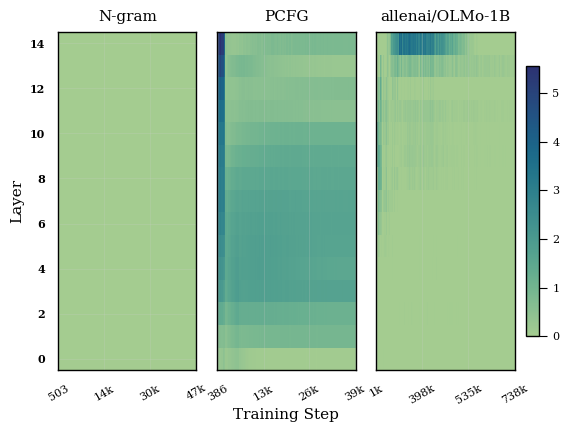

In [6]:
all_values = pd.concat([
    ngram_df['hydra_value'], 
    pcfg_df['hydra_value'], 
    olmo_df['hydra_value']
])
all_values = -all_values.clip(upper=0)
vmin = all_values.min()
vmax = all_values.max()

fig, axes = plt.subplots(1, 3, figsize=(PAPER_WIDTH_IN, PAPER_HEIGHT_IN))

experiments = [
    ('N-gram', ngram_df, '#8FBAC8'),
    ('PCFG', pcfg_df, '#B7A9D1'),
    ('allenai/OLMo-1B', olmo_df, '#F2B5A7'),
]

im = None

for idx, (name, df, color) in enumerate(experiments):
    pivot_data = -df.pivot(index='layer', columns='step', values='hydra_value').clip(upper=0)
    
    im = axes[idx].imshow(
        pivot_data.values,
        aspect='auto',
        cmap='crest',
        interpolation='nearest',
        vmin=vmin,
        vmax=vmax,
        origin='lower' 
    )
    
    if idx == 0:
        axes[idx].set_ylabel('Layer', fontsize=11, color='black')
        fig.canvas.draw()
        for label in axes[idx].get_yticklabels():
            label.set_fontweight('bold')
    else:
        axes[idx].set_ylabel('')
        axes[idx].set_yticks([]) 
    
    axes[idx].set_title(name, fontsize=11, pad=8, color='black')
    axes[idx].tick_params(axis='x', colors='black', labelsize=8)
    axes[idx].tick_params(axis='y', colors='black', labelsize=8)
    
    if idx == 1:
        axes[idx].set_xlabel('Training Step', fontsize=11, color='black')
    
    n_ticks = 4
    step_positions = np.linspace(0, len(pivot_data.columns) - 1, n_ticks, dtype=int)
    step_values = [int(pivot_data.columns[i]) for i in step_positions]
    step_labels = [f'{v/1000:.0f}k' if v >= 1000 else str(v) for v in step_values]
    
    axes[idx].set_xticks(step_positions)
    axes[idx].set_xticklabels(step_labels, rotation=30, ha='center')

for ax in axes:
    for spine in ax.spines.values():
        spine.set_color('black')

fig.subplots_adjust(right=0.9, wspace=0.15) 

cbar = fig.colorbar(im, ax=axes, location='right', shrink=0.8, pad=0.02)
cbar.ax.tick_params(labelsize=8, colors='black')
for spine in cbar.ax.spines.values():
    spine.set_color('black')

save_figure(fig, "hydra_effect_heatmaps.pdf")
print(f"Saved figure to: results/figures/hydra_effect_heatmaps.pdf")

plt.show()